<a href="https://colab.research.google.com/github/samihannn/aml-exps-samihan/blob/main/AML_Exp_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Please upload 'bank-additional.zip' below:


Saving bank-additional.zip to bank-additional.zip
File unzipped successfully.
Dataset loaded successfully!
Number of Instances: 41188

--- Model Performance ---
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      7310
           1       0.57      0.28      0.38       928

    accuracy                           0.90      8238
   macro avg       0.74      0.63      0.66      8238
weighted avg       0.88      0.90      0.88      8238



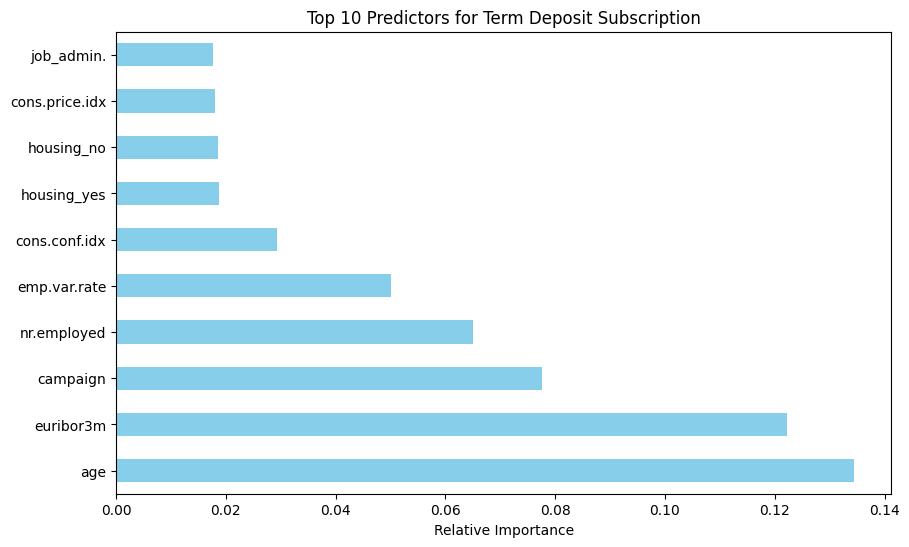

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import zipfile
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score


print("Please upload 'bank-additional.zip' below:")
uploaded = files.upload()


zip_filename = 'bank-additional.zip'
if os.path.exists(zip_filename):
    with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
        zip_ref.extractall('.')
    print("File unzipped successfully.")
else:
    print("Error: Zip file not found. Please ensure the filename is exactly 'bank-additional.zip'.")


file_path = 'bank-additional/bank-additional-full.csv'

if os.path.exists(file_path):

    df = pd.read_csv(file_path, sep=';')
    print("Dataset loaded successfully!")
    print(f"Number of Instances: {len(df)}")
else:
    print(f"Error: Could not find {file_path}. Check if the folder structure matches.")


if 'df' in locals():

    df_model = df.drop(columns=['duration'])


    df_model['y'] = df_model['y'].map({'yes': 1, 'no': 0})


    df_final = pd.get_dummies(df_model)


    X = df_final.drop('y', axis=1)
    y = df_final['y']


    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


    model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    print("\n--- Model Performance ---")
    print(classification_report(y_test, y_pred))


    feat_importances = pd.Series(model.feature_importances_, index=X.columns)
    plt.figure(figsize=(10,6))
    feat_importances.nlargest(10).plot(kind='barh', color='skyblue')
    plt.title("Top 10 Predictors for Term Deposit Subscription")
    plt.xlabel("Relative Importance")
    plt.show()

In [ ]:
# 1. Create a sample customer profile (adjust these values to test different scenarios)
# Note: We must match the exact columns created by pd.get_dummies in the previous step
sample_customer = X_test.iloc[[0]].copy()

# 2. Use the model to predict (0 = No, 1 = Yes)
prediction = model.predict(sample_customer)
probability = model.predict_proba(sample_customer)

# 3. Output the result
result = "Yes" if prediction[0] == 1 else "No"
confidence = probability[0][prediction[0]] * 100

print(f"--- Prediction Result ---")
print(f"Will the customer subscribe? {result}")
print(f"Model Confidence: {confidence:.2f}%")

--- Prediction Result ---
Will the customer subscribe? No
Model Confidence: 90.00%


In [ ]:
# 1. Generate predictions for all customers in the test set
test_predictions = model.predict(X_test)
test_probabilities = model.predict_proba(X_test)[:, 1] # Probability of 'Yes'

# 2. Create a summary DataFrame
results_df = pd.DataFrame({
    'Actual_Outcome': y_test.values,
    'Predicted_Outcome': test_predictions,
    'Subscription_Probability': test_probabilities
})

# 3. Sort by highest probability to find "Hot Leads"
hot_leads = results_df.sort_values(by='Subscription_Probability', ascending=False)

print("Top 5 Customers Most Likely to Subscribe:")
print(hot_leads.head())

Top 5 Customers Most Likely to Subscribe:
      Actual_Outcome  Predicted_Outcome  Subscription_Probability
1611               1                  1                      1.00
7956               1                  1                      0.98
4500               1                  1                      0.97
3538               1                  1                      0.96
3272               1                  1                      0.96
